In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', '..')))

import argparse
from pprint import pp
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
import json
import os
from omegaconf import OmegaConf
from torch.utils.tensorboard import SummaryWriter

from lpn.utils import load_dataset, load_config
from lpn.utils import get_model
from lpn.utils import get_loss_hparams_and_lr, get_loss
from lpn.utils import trainer
from lpn.utils import utils
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
lpn_model_config_path = os.path.join('..','models','lpn','s=0.1','model_config.json')
lpn_model_weight_path = os.path.join('..','models','lpn','s=0.1','model.pt')

lpn_model_config = load_config(lpn_model_config_path)
lpn_model = get_model(lpn_model_config)
lpn_model.load_state_dict(torch.load(lpn_model_weight_path)['model_state_dict'])
lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(64, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): Con

In [4]:
ne_lpn_model_config_path = os.path.join('..','models','ne_lpn','s=0.1','model_config.json')
ne_lpn_model_weight_path = os.path.join('..','models','ne_lpn','s=0.1','model.pt')
ne_lpn_model_config = load_config(ne_lpn_model_config_path)
ne_lpn_model = get_model(ne_lpn_model_config)
ne_lpn_model.load_state_dict(torch.load(ne_lpn_model_weight_path)['model_state_dict'])
ne_lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
    (6): Conv2d(64, 64, kernel_size=(16, 16), stride=(1, 1), bias=False, padding_mode=reflect)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
    (1): Conv2d(3, 64, kernel_siz

In [ ]:
ne_lpn_by_forward_model_config_path = '../models/ne_by_forwad_lpn/s=0.1/model_config.json'
ne_lpn_by_forward_model_weight_path = '../models/ne_by_forwad_lpn/s=0.1/model.pt'
ne_lpn_by_forward_model_config = load_config(ne_lpn_by_forward_model_config_path)
ne_lpn_by_forward_model = get_model(ne_lpn_by_forward_model_config)
ne_lpn_by_forward_model.load_state_dict(torch.load(ne_lpn_by_forward_model_weight_path)['model_state_dict'])
ne_lpn_by_forward_model.to(device)

FileNotFoundError: [Errno 2] No such file or directory: '../models/ne_by_forward_lpn/s=0.1/model_config.json'

In [ ]:
dataset_config_path = os.path.join('..','configs','dataset.json')
dataset_config = load_config(dataset_config_path)
dataset_config['params']['root'] = '../../../data/bsds500'
test_dataset = load_dataset(dataset_config, 'test')
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)

dataset:  bsds500


In [ ]:
def visualize_dataloader(dataloader):
    for i, data in enumerate(dataloader):
        image = data['image'].squeeze(0).permute(1, 2, 0).cpu().numpy()
        plt.imshow(image)
        plt.show()
        if i == 5:
            break
#visualize_dataloader(test_dataloader)  #uncomment to visualize

In [ ]:
noise_levels = [0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7]

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as skimage_psnr
from skimage.metrics import structural_similarity as skimage_ssim

def evaluate_model(model, dataloader, noise_levels):
    model.eval()
    avg_psnr_list = []
    avg_ssim_list = []

    for noise in tqdm(noise_levels, total=len(noise_levels)):
        psnr_list = []
        ssim_list = []
        for i, data in tqdm(enumerate(dataloader), total=len(dataloader)):
            img = data['image'].to(device)
            noise_tensor = torch.randn_like(img) * noise
            noisy_img = img + noise_tensor

            with torch.no_grad():
                denoised_img = model(noisy_img)

            img_np = img.squeeze(0).permute(1, 2, 0).cpu().detach().numpy() 
            denoised_np = denoised_img.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()

            psnr = skimage_psnr(img_np, denoised_np, data_range=1.0)
            ssim = skimage_ssim(img_np, denoised_np, data_range=1.0, channel_axis=-1)

            psnr_list.append(psnr)
            ssim_list.append(ssim)
        avg_psnr = np.mean(psnr_list)
        avg_ssim = np.mean(ssim_list)
        avg_psnr_list.append(avg_psnr)
        avg_ssim_list.append(avg_ssim)
        print(f"Average PSNR for noise level {noise}: {avg_psnr:.2f}")
        print(f"Average SSIM for noise level {noise}: {avg_ssim:.4f}")
    return avg_psnr_list, avg_ssim_list


In [ ]:
lpn_psnr, lpn_ssim = evaluate_model(lpn_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:04<00:28,  4.08s/it]

Average PSNR for noise level 0.05: 31.19
Average SSIM for noise level 0.05: 0.8939


 25%|██▌       | 2/8 [00:06<00:19,  3.33s/it]

Average PSNR for noise level 0.1: 29.46
Average SSIM for noise level 0.1: 0.8538


 38%|███▊      | 3/8 [00:09<00:15,  3.08s/it]

...

Average PSNR for noise level 0.5: 10.55
Average SSIM for noise level 0.5: 0.1356


 88%|████████▊ | 7/8 [00:20<00:02,  2.86s/it]

Average PSNR for noise level 0.6: 9.09
Average SSIM for noise level 0.6: 0.1040


100%|██████████| 8/8 [00:23<00:00,  2.96s/it]

Average PSNR for noise level 0.7: 8.07
Average SSIM for noise level 0.7: 0.0839


In [ ]:
ne_lpn_psnr, ne_lpn_ssim = evaluate_model(ne_lpn_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:03<00:23,  3.43s/it]

Average PSNR for noise level 0.05: 24.62
Average SSIM for noise level 0.05: 0.7859


 25%|██▌       | 2/8 [00:06<00:20,  3.34s/it]

Average PSNR for noise level 0.1: 24.24
Average SSIM for noise level 0.1: 0.7441


 38%|███▊      | 3/8 [00:09<00:16,  3.24s/it]

...

Average PSNR for noise level 0.5: 16.91
Average SSIM for noise level 0.5: 0.3105


 88%|████████▊ | 7/8 [00:22<00:03,  3.30s/it]

Average PSNR for noise level 0.6: 15.44
Average SSIM for noise level 0.6: 0.2545


100%|██████████| 8/8 [00:26<00:00,  3.30s/it]

Average PSNR for noise level 0.7: 14.17
Average SSIM for noise level 0.7: 0.2105


In [ ]:
ne_by_forward_psnr, ne_by_forward_ssim = evaluate_model(ne_lpn_by_forward_model, test_dataloader, noise_levels)

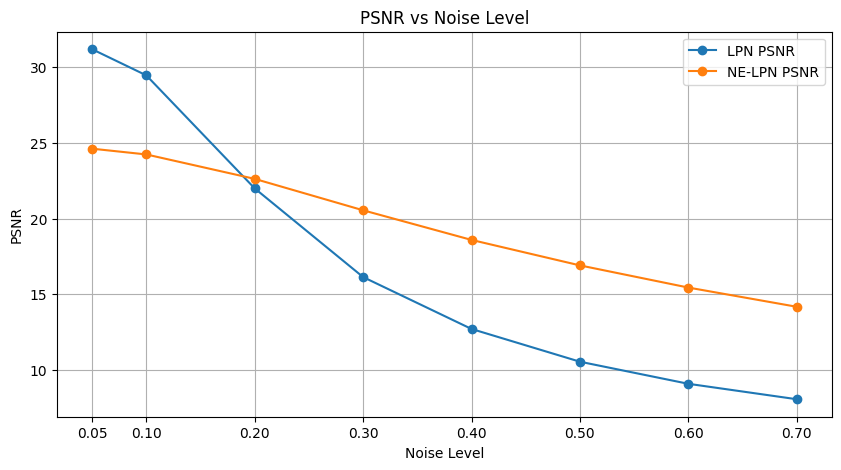

In [ ]:
# plot noise levels vs psnr
plt.figure(figsize=(10, 5))
plt.plot(noise_levels, lpn_psnr, label='LPN PSNR', marker='o')
plt.plot(noise_levels, ne_lpn_psnr, label='NE-LPN PSNR', marker='o')
plt.plot(noise_levels, ne_by_forward_psnr, label='NE-LPN by Forward PSNR', marker='o')
plt.xlabel('Noise Level')
plt.ylabel('PSNR')
plt.title('PSNR vs Noise Level')
plt.xticks(noise_levels)
plt.grid()
plt.legend()